In [6]:
import pandas as pd
import numpy as np
from scipy.stats import entropy
from collections import Counter
import os
import re
import matplotlib.pyplot as plt
from collections import defaultdict

In [17]:
animes_path = r'..\data\anime.csv'
relations_path = r'..\data\anime_anime.csv'
clusters_path = r'..\data\review_clustering'
clusters_file_type = '.csv'


structural_weight = 0.5
recommendation_weight = 0.5

size_weight = 0.4
relation_weight = 0.3
metadata_weight = 0.3

In [8]:
cluster_files = []
for filename in os.listdir(clusters_path):
    if filename.endswith(clusters_file_type):
        cluster_files.append(filename)

In [9]:
def calculate_cluster_fidelity(cluster_csv_path, anime_anime_csv_path, anime_csv_path,
                             structural_weight=0.7, recommendation_weight=0.3,
                             size_weight=0.3, relation_weight=0.4, metadata_weight=0.3):
    """
    Calculate cluster fidelity score based on size balance, relation consistency, and metadata purity.
    
    Parameters:
    - cluster_csv_path: Path to CSV with columns "anime_id,cluster"
    - anime_anime_csv_path: Path to anime relations CSV
    - anime_csv_path: Path to anime metadata CSV
    - structural_weight: Weight for structural relations (sequel/prequel) in relation consistency
    - recommendation_weight: Weight for user recommendations in relation consistency
    - size_weight: Weight for size balance in composite score
    - relation_weight: Weight for relation consistency in composite score
    - metadata_weight: Weight for metadata purity in composite score
    
    Returns:
    - dict with individual scores and composite fidelity score
    """
    
    # Load data
    cluster_df = pd.read_csv(cluster_csv_path)
    anime_anime_df = pd.read_csv(anime_anime_csv_path)
    anime_df = pd.read_csv(anime_csv_path)
    
    # Create anime_id to cluster mapping
    anime_to_cluster = dict(zip(cluster_df['anime_id'], cluster_df['cluster']))
    cluster_labels = cluster_df['cluster'].values
    
    # 1. Size Balance (entropy of cluster sizes)
    unique, counts = np.unique(cluster_labels, return_counts=True)
    probabilities = counts / len(cluster_labels)
    # Normalize entropy to [0,1] range
    max_possible_entropy = np.log(len(unique))  # Maximum entropy occurs when all clusters are equal size
    size_balance = entropy(probabilities) / max_possible_entropy if max_possible_entropy > 0 else 0.0
    
    # 2. Relation Consistency (both structural and recommendations)
    
    # 2a. Structural Relations
    structural_relations = ['Sequel', 'Prequel', 'Spin-off', 'Side story', 
                           'Parent story', 'Alternative version', 'Full story',
                           'Character', 'Alternative setting', 'Summary']
    
    structural_pairs = anime_anime_df[
        (anime_anime_df['related'] == 1) &
        (anime_anime_df['relation_type'].isin(structural_relations))
    ]
    
    structural_consistent = 0
    structural_total = 0
    
    for _, row in structural_pairs.iterrows():
        anime_a, anime_b = row['animeA'], row['animeB']
        
        if anime_a not in anime_to_cluster or anime_b not in anime_to_cluster:
            continue
            
        structural_total += 1
        if anime_to_cluster[anime_a] == anime_to_cluster[anime_b]:
            structural_consistent += 1
    
    structural_consistency = structural_consistent / structural_total if structural_total > 0 else 0.0
    
    # 2b. User Recommendations (weighted by number of recommenders)
    recommendation_pairs = anime_anime_df[anime_anime_df['recommendation'] == 1]

    recommendation_weighted_same = 0.0
    recommendation_total_weight = 0.0
    recommendation_pairs_count = 0

    for _, row in recommendation_pairs.iterrows():
        anime_a, anime_b = row['animeA'], row['animeB']
    
        if anime_a not in anime_to_cluster or anime_b not in anime_to_cluster:
            continue
        
        recommendation_pairs_count += 1
        # Weight by number of recommenders (log scale to prevent extreme values)
        weight = np.log(row['num_recommenders'] + 1) if pd.notna(row['num_recommenders']) else 1.0
        recommendation_total_weight += weight
        
        if anime_to_cluster[anime_a] == anime_to_cluster[anime_b]:
            recommendation_weighted_same += weight

    recommendation_consistency = recommendation_weighted_same / recommendation_total_weight if recommendation_total_weight > 0 else 0.0
    
    # Combined relation consistency
    if structural_total > 0 and recommendation_pairs_count > 0:
        relation_consistency = (structural_weight * structural_consistency + 
                               recommendation_weight * recommendation_consistency)
    elif structural_total > 0:
        relation_consistency = structural_consistency
    elif recommendation_pairs_count > 0:
        relation_consistency = recommendation_consistency
    else:
        relation_consistency = 0.0
    
    # 3. Metadata Purity
    def calculate_metadata_purity(column):
        cluster_purities = []
        
        for cluster_id in np.unique(cluster_labels):
            # Get anime in this cluster
            cluster_anime = [aid for aid, cid in anime_to_cluster.items() if cid == cluster_id]
            
            if len(cluster_anime) < 2:  # Need at least 2 items
                continue
                
            # Get metadata for these anime
            cluster_metadata = anime_df[anime_df['anime_id'].isin(cluster_anime)][column].dropna()
            
            if len(cluster_metadata) == 0:
                continue
            
            # Handle pipe-separated values (like "Action|Adventure")
            all_values = []
            for meta in cluster_metadata:
                if pd.isna(meta):
                    continue
                if '|' in str(meta):
                    all_values.extend(str(meta).split('|'))
                else:
                    all_values.append(str(meta))
            
            if not all_values:
                continue
                
            # Calculate purity as most common value frequency
            value_counts = Counter(all_values)
            most_common_count = value_counts.most_common(1)[0][1]
            purity = most_common_count / len(all_values)
            cluster_purities.append(purity)
        
        return np.mean(cluster_purities) if cluster_purities else 0.0
    
    # Calculate purity for available metadata columns
    purity_scores = {}
    if 'genres' in anime_df.columns:
        purity_scores['genre_purity'] = calculate_metadata_purity('genres')
    if 'studios' in anime_df.columns:
        purity_scores['studio_purity'] = calculate_metadata_purity('studios')
    if 'type' in anime_df.columns:
        purity_scores['type_purity'] = calculate_metadata_purity('type')
    
    # Average metadata purity
    metadata_purity = np.mean(list(purity_scores.values())) if purity_scores else 0.0
    
    # Composite fidelity score with custom weights
    composite_fidelity = (relation_weight * relation_consistency + 
                         size_weight * size_balance + 
                         metadata_weight * metadata_purity)
    
    return {
        'size_balance': size_balance,
        'structural_consistency': structural_consistency,
        'recommendation_consistency': recommendation_consistency,
        'relation_consistency': relation_consistency,
        'metadata_purity': metadata_purity,
        'metadata_breakdown': purity_scores,
        'composite_fidelity': composite_fidelity,
        'structural_pairs_evaluated': structural_total,
        'recommendation_pairs_evaluated': recommendation_pairs_count  
    }

In [10]:
# Store results: {method: [(num_clusters, metrics_dict), ...]}
results_by_method = defaultdict(list)

for file in cluster_files:    
    cluster_file_path = os.path.join(clusters_path, file)
    result = calculate_cluster_fidelity(
        cluster_file_path,
        relations_path,
        animes_path,
        structural_weight=structural_weight,
        recommendation_weight=recommendation_weight,
        size_weight=size_weight,
        relation_weight=relation_weight,
        metadata_weight=metadata_weight
    )
    
    # Extract method and cluster count from filename
    match = re.match(r"([a-zA-Z_0-9]+)_(\d+)_clusters\.csv$", file)
    if match:
        method = match.group(1)
        num_clusters = int(match.group(2))
        
        # Store all base metrics (no composite fidelity)
        results_by_method[method].append((
            num_clusters,
            {
                "size_balance": result['size_balance'],
                "structural_consistency": result['structural_consistency'],
                "structural_pairs_evaluated": result['structural_pairs_evaluated'],
                "recommendation_consistency": result['recommendation_consistency'],
                "recommendation_pairs_evaluated": result['recommendation_pairs_evaluated'],
                "relation_consistency": result['relation_consistency'],
                "metadata_purity": result['metadata_purity'],
                "metadata_breakdown": result['metadata_breakdown'],
            }
        ))
    
    # 🔹 Preserve all the printouts from before
    print("\n" + "="*50)
    print(f"📊 CLUSTERING FIDELITY RESULTS FOR {file}" )
    print("="*50)
    print(f"Size Balance (Entropy): {result['size_balance']:.3f}")
    print(f"Structural Consistency: {result['structural_consistency']:.3f} ({result['structural_pairs_evaluated']} pairs)")
    print(f"Recommendation Consistency: {result['recommendation_consistency']:.3f} ({result['recommendation_pairs_evaluated']} pairs)")
    print(f"Combined Relation Consistency: {result['relation_consistency']:.3f}")
    print(f"Metadata Purity: {result['metadata_purity']:.3f}")
    if result['metadata_breakdown']:
        for meta_type, score in result['metadata_breakdown'].items():
            print(f"  └─ {meta_type}: {score:.3f}")
    print(f"Original Composite Fidelity (from function): {result['composite_fidelity']:.3f}")


📊 CLUSTERING FIDELITY RESULTS FOR hierarchical_ward_10_clusters.csv
Size Balance (Entropy): 0.943
Structural Consistency: 0.363 (7689 pairs)
Recommendation Consistency: 0.257 (46260 pairs)
Combined Relation Consistency: 0.310
Metadata Purity: 0.314
  └─ genre_purity: 0.130
  └─ studio_purity: 0.106
  └─ type_purity: 0.707
Original Composite Fidelity (from function): 0.501

📊 CLUSTERING FIDELITY RESULTS FOR hierarchical_ward_11_clusters.csv
Size Balance (Entropy): 0.938
Structural Consistency: 0.356 (7689 pairs)
Recommendation Consistency: 0.238 (46260 pairs)
Combined Relation Consistency: 0.297
Metadata Purity: 0.312
  └─ genre_purity: 0.130
  └─ studio_purity: 0.110
  └─ type_purity: 0.696
Original Composite Fidelity (from function): 0.494

📊 CLUSTERING FIDELITY RESULTS FOR hierarchical_ward_12_clusters.csv
Size Balance (Entropy): 0.936
Structural Consistency: 0.308 (7689 pairs)
Recommendation Consistency: 0.231 (46260 pairs)
Combined Relation Consistency: 0.270
Metadata Purity: 0.30

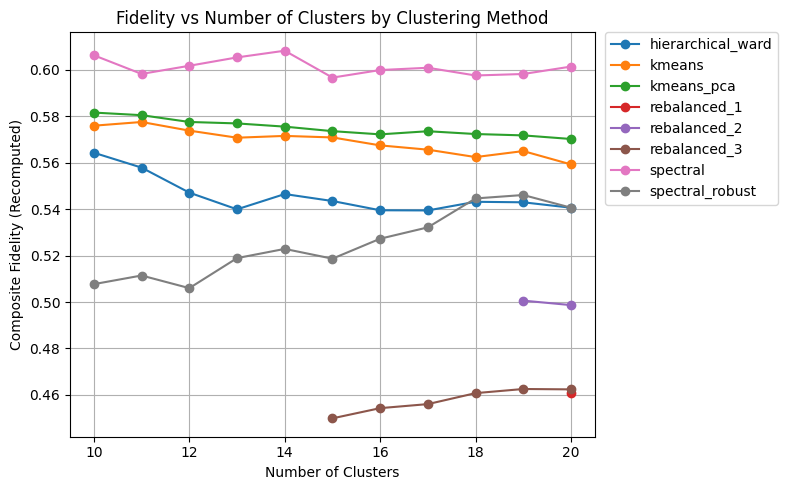

In [18]:
plt.figure(figsize=(8, 5))

for method, data in results_by_method.items():
    recomputed = []
    for num_clusters, metrics in data:
        composite = (
            size_weight * metrics["size_balance"]
            + relation_weight * metrics["relation_consistency"]
            + metadata_weight * metrics["metadata_purity"]
        )
        recomputed.append((num_clusters, composite))
    
    # Sort & plot
    recomputed.sort(key=lambda x: x[0])
    x_vals, y_vals = zip(*recomputed)
    plt.plot(x_vals, y_vals, marker='o', label=method)

plt.xlabel("Number of Clusters")
plt.ylabel("Composite Fidelity (Recomputed)")
plt.title("Fidelity vs Number of Clusters by Clustering Method")
plt.grid(True)

# Legend outside top-left corner
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0)

plt.tight_layout()
plt.show()